In [1]:
import os

# Set working directory to project root always`n
# Works regardless of where the notebook is saved`n
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Load preprocessed arrays
X_train = np.load('outputs/X_train_telecom.npy')
X_test  = np.load('outputs/X_test_telecom.npy')
y_train = np.load('outputs/y_train_telecom.npy')
y_test  = np.load('outputs/y_test_telecom.npy')

feature_names = pd.read_csv(
    'outputs/telecom_feature_names.csv'
).squeeze().tolist()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Features:", len(feature_names))

X_train: (5634, 23)
X_test : (1409, 23)
Features: 23


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully")
print("Number of trees:", rf_model.n_estimators)

Random Forest trained successfully
Number of trees: 100


In [4]:
y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print("="*40)
print("  Random Forest â€” Telecom")
print("="*40)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("="*40)
print(classification_report(
    y_test, y_pred,
    target_names=['No Churn','Churn']
))

  Random Forest â€” Telecom
  Accuracy  : 0.7899
  Precision : 0.6291
  Recall    : 0.5080
  F1 Score  : 0.5621
  ROC-AUC   : 0.8244
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


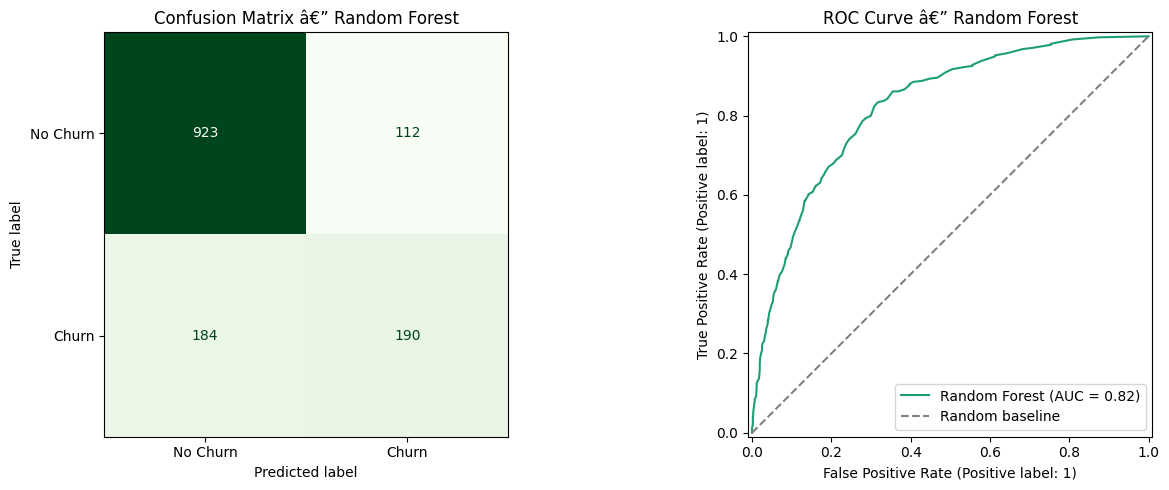

In [5]:
import os
os.makedirs('outputs/plots/telecom', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn','Churn']
).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix â€” Random Forest')

# ROC curve
RocCurveDisplay.from_predictions(
    y_test, y_proba,
    ax=axes[1],
    name='Random Forest',
    color='#1D9E75'
)
axes[1].plot([0,1],[0,1],'--',color='gray',
             label='Random baseline')
axes[1].set_title('ROC Curve â€” Random Forest')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    'outputs/plots/telecom/08_rf_evaluation.png',
    bbox_inches='tight'
)
plt.show()

Top 10 most important features:
                       Feature  Importance
                  TotalCharges    0.197181
                MonthlyCharges    0.176819
                        tenure    0.167949
   InternetService_Fiber optic    0.046506
PaymentMethod_Electronic check    0.040633
             Contract_Two year    0.033052
                        gender    0.029247
              PaperlessBilling    0.027324
                OnlineSecurity    0.024517
                   TechSupport    0.022876


C:\Users\DELL\AppData\Local\Temp\ipykernel_31692\4058729266.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


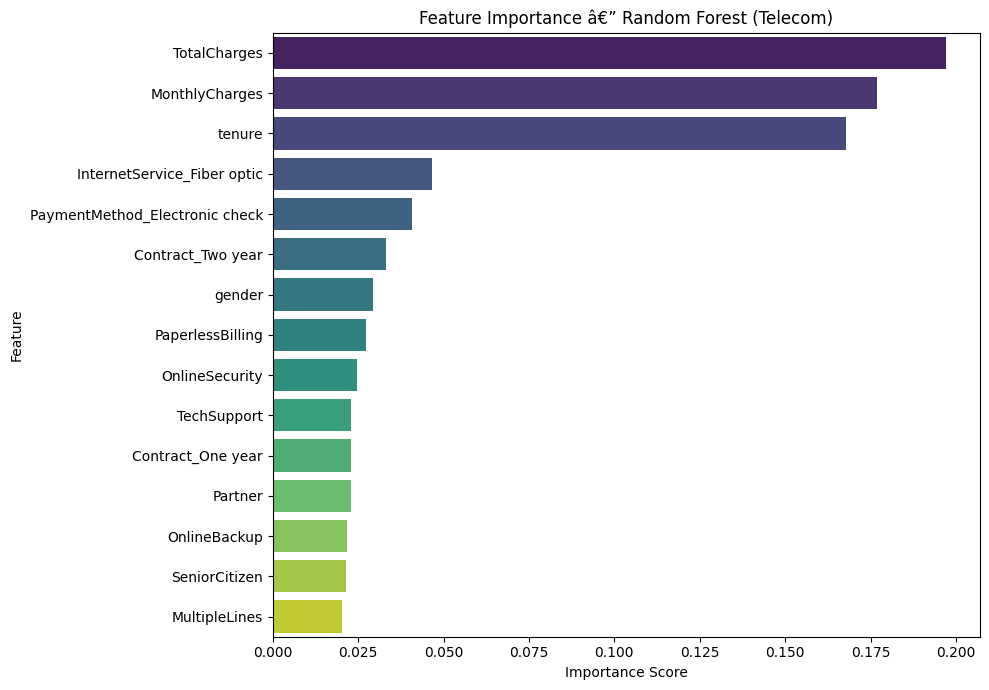

In [6]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Top 10 most important features:")
print(feat_df.head(10).to_string(index=False))

# Plot top 15
plt.figure(figsize=(10, 7))
sns.barplot(
    data=feat_df.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Feature Importance â€” Random Forest (Telecom)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(
    'outputs/plots/telecom/09_rf_feature_importance.png',
    bbox_inches='tight'
)
plt.show()

In [7]:
existing = pd.read_csv('outputs/results/telecom_results.csv')

new_row = pd.DataFrame([{
    'Sector'   : 'Telecom',
    'Model'    : 'Random Forest',
    'Accuracy' : round(acc, 4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec, 4),
    'F1'       : round(f1, 4),
    'ROC_AUC'  : round(auc, 4)
}])

updated = pd.concat([existing, new_row], ignore_index=True)
updated.to_csv(
    'outputs/results/telecom_results.csv',
    index=False
)

print("Results table so far:")
print(updated.to_string(index=False))

Results table so far:
 Sector               Model  Accuracy  Precision  Recall     F1  ROC_AUC
Telecom Logistic Regression    0.8055     0.6582  0.5561 0.6029   0.8421
Telecom       Random Forest    0.7899     0.6291  0.5080 0.5621   0.8244


In [8]:
import joblib
scaler = joblib.load('outputs/scaler_telecom.pkl')

# High risk customer
high_risk = pd.DataFrame(
    [np.zeros(len(feature_names))],
    columns=feature_names
)
high_risk['gender']           = 1
high_risk['SeniorCitizen']    = 0
high_risk['tenure']           = 2
high_risk['MonthlyCharges']   = 85.0
high_risk['TotalCharges']     = 170.0
high_risk['PhoneService']     = 1
high_risk['TechSupport']      = 0
high_risk['OnlineSecurity']   = 0
high_risk['PaperlessBilling'] = 1

col = [c for c in feature_names if 'Fiber' in c]
if col: high_risk[col[0]] = 1
col = [c for c in feature_names if 'Electronic' in c]
if col: high_risk[col[0]] = 1

high_risk[['tenure','MonthlyCharges','TotalCharges']] = \
    scaler.transform(
        high_risk[['tenure','MonthlyCharges','TotalCharges']]
    )

pred1 = rf_model.predict(high_risk.values)
prob1 = rf_model.predict_proba(high_risk.values)[:,1]
print(f"High-risk â†’ {'CHURN' if pred1[0]==1 else 'STAY'} | {prob1[0]*100:.1f}%")

# Loyal customer
loyal = pd.DataFrame(
    [np.zeros(len(feature_names))],
    columns=feature_names
)
loyal['gender']           = 1
loyal['tenure']           = 60
loyal['MonthlyCharges']   = 25.0
loyal['TotalCharges']     = 1500.0
loyal['TechSupport']      = 1
loyal['OnlineSecurity']   = 1

col = [c for c in feature_names if 'Two' in c]
if col: loyal[col[0]] = 1
col = [c for c in feature_names if 'Mailed' in c]
if col: loyal[col[0]] = 1

loyal[['tenure','MonthlyCharges','TotalCharges']] = \
    scaler.transform(
        loyal[['tenure','MonthlyCharges','TotalCharges']]
    )

pred2 = rf_model.predict(loyal.values)
prob2 = rf_model.predict_proba(loyal.values)[:,1]
print(f"Loyal     â†’ {'CHURN' if pred2[0]==1 else 'STAY'} | {prob2[0]*100:.1f}%")

High-risk â†’ CHURN | 73.0%
Loyal     â†’ STAY | 6.0%
